# Handwritten Digit Recognition using Logistic Regression and CNN

**By:** Rhythm Subedi

**Dataset:** MNIST (Modified National Institute of Standards and Technology)

---
## 1. Problem Definition

The goal of this project is to build a machine learning model that recognizes handwritten digits (0-9) from 28×28 grayscale images, and to compare the performance of two different approaches: Logistic Regression using the One vs All strategy, where 10 binary classifiers each learn to distinguish one digit or not that digit. And a Convolutional Neural Network (CNN) with a VGG-like architecture that captures patterns in image data. This comparison demonstrates the difference between a simple, interpretable model and a more complex deep learning approach. 

---
## 2. Data Collection

### Dataset: MNIST
The MNIST dataset is a dataset containing images of handwritten digits. Images are organized in subfolders named '0' through '9', where each subfolder contains images of that digit

### Features and Target Variable

|  | Description |
|--------|-------------|
| **Input Features** | 784 pixel values (28×28 grayscale image flattened) |
| **Target Variable** | Digit label (0-9) |

In [32]:
# Import required libraries
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [33]:
# Load data from folder using TensorFlow
# Dataset should be organized in subfolders '0' to '9' in the 'train' directory
train_dir = 'train' 
img_height, img_width = 28, 28 

# Create training dataset (90% of data)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    color_mode='grayscale',
    batch_size=32,
    image_size=(img_height, img_width),
    shuffle=True,
    validation_split=0.1,
    subset='training',
    seed=123
)

# Create validation dataset (10% of data)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    color_mode='grayscale',
    batch_size=32,
    image_size=(img_height, img_width),
    shuffle=True,
    validation_split=0.1,
    subset='validation',
    seed=123
)

Found 60000 files belonging to 10 classes.
Using 54000 files for training.
Found 60000 files belonging to 10 classes.
Using 6000 files for validation.


In [34]:
# Normalize datasets to [0,1] for consistent scaling
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
val_dataset = val_dataset.map(lambda x, y: (x / 255.0, y))

In [35]:
x_train_flat = []
y_train = []
for images, labels in train_dataset.as_numpy_iterator():
    x_train_flat.append(images.reshape(-1, 784) / 255.0)  # Flatten and normalize
    y_train.append(labels)

x_train_flat = np.vstack(x_train_flat)
y_train = np.concatenate(y_train)

print(f"Training data shape: {x_train_flat.shape}")
print(f"Training labels shape: {y_train.shape}")

Training data shape: (54000, 784)
Training labels shape: (54000,)


In [36]:
# Extract validation data
x_val_flat = []
y_val = []
for images, labels in val_dataset.as_numpy_iterator():
    x_val_flat.append(images.reshape(-1, 784) / 255.0)
    y_val.append(labels)

x_val_flat = np.vstack(x_val_flat)
y_val = np.concatenate(y_val)

print(f"Validation data shape: {x_val_flat.shape}")
print(f"Validation labels shape: {y_val.shape}")

Validation data shape: (6000, 784)
Validation labels shape: (6000,)


In [37]:
# Get class names from full dataset 
full_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    color_mode='grayscale',
    batch_size=32,
    image_size=(img_height, img_width),
    shuffle=False,
    validation_split=None  # No split for full
)
class_names = full_dataset.class_names
print(f"Classes found: {class_names}")
num_classes = len(class_names)

# Then proceed with your train/val datasets...

Found 60000 files belonging to 10 classes.
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


---
## 3. EDA & Preprocessing

MNIST dataset contains grayscale images where pixel values range from 0 to 255. No missing values in image data and no traditional outliers in the sense of erroneous data points.

### Preprocessing Steps

**1. Normalization:** Pixel values are divided by 255 to scale to [0, 1] range

**2. Flattening:** 28×28 images are flattened to 784-dimensional vectors for logistic regression

**3. Feature Scaling:** Features are standardized to have mean=0 and std=1

**4. Train-Validation Split:** 90% training, 10% validation using TensorFlow's builtin function

**5. Intercept Addition:** A bias term (intercept) is added as the first feature for logistic regression

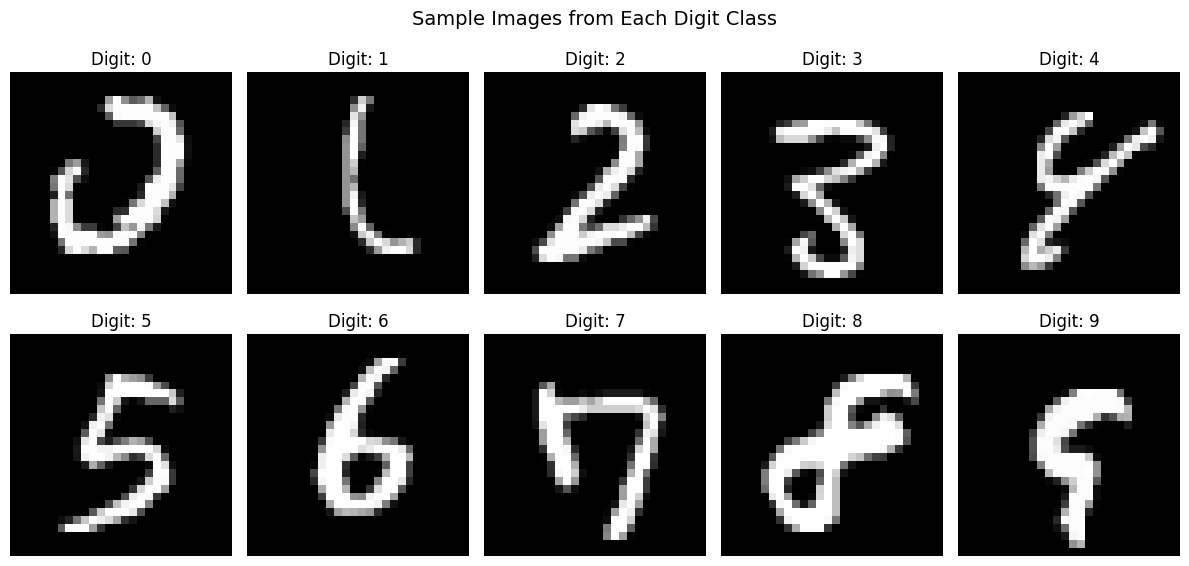

In [39]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Images from Each Digit Class', fontsize=14)

# Display one sample per class
for images, labels in train_dataset.take(1):
    for i, ax in enumerate(axes.flat):
        # Find first image of class i
        idx = np.where(labels.numpy() == i)[0]
        if len(idx) > 0:
            ax.imshow(images[idx[0]].numpy().squeeze(), cmap='gray')
            ax.set_title(f'Digit: {i}')
        ax.axis('off')
plt.tight_layout()
plt.show()

Class distribution in training set:
  Digit 0: 5329 samples (9.9%)
  Digit 1: 6043 samples (11.2%)
  Digit 2: 5358 samples (9.9%)
  Digit 3: 5529 samples (10.2%)
  Digit 4: 5274 samples (9.8%)
  Digit 5: 4916 samples (9.1%)
  Digit 6: 5339 samples (9.9%)
  Digit 7: 5646 samples (10.5%)
  Digit 8: 5212 samples (9.7%)
  Digit 9: 5354 samples (9.9%)


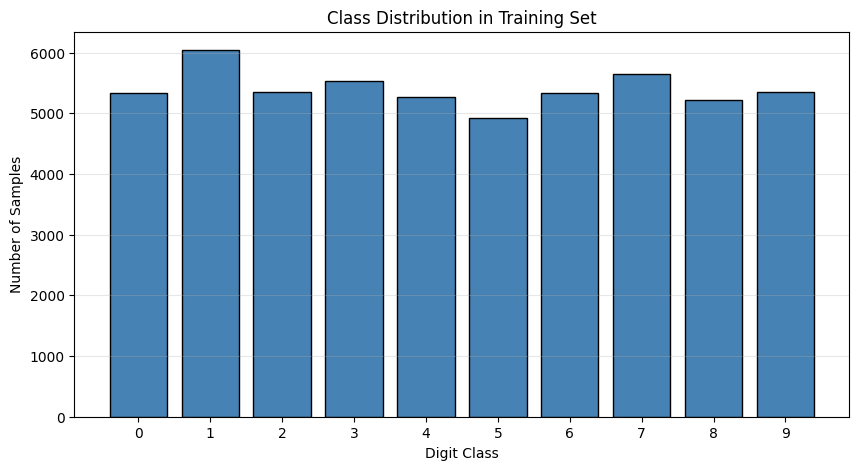

In [40]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution in training set:")
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples ({100*c/len(y_train):.1f}%)")

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Set')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [41]:
# Preprocessing: Add intercept for logistic regression
intercept_train = np.ones((x_train_flat.shape[0], 1))
x_train_with_intercept = np.concatenate((intercept_train, x_train_flat), axis=1)

intercept_val = np.ones((x_val_flat.shape[0], 1))
x_val_with_intercept = np.concatenate((intercept_val, x_val_flat), axis=1)

print(f"Training data with intercept: {x_train_with_intercept.shape}")
print(f"Validation data with intercept: {x_val_with_intercept.shape}")

Training data with intercept: (54000, 785)
Validation data with intercept: (6000, 785)


In [42]:
# Feature scaling
scaler = StandardScaler()
x_train_scaled = x_train_with_intercept.copy()
x_train_scaled[:, 1:] = scaler.fit_transform(x_train_with_intercept[:, 1:])

x_val_scaled = x_val_with_intercept.copy()
x_val_scaled[:, 1:] = scaler.transform(x_val_with_intercept[:, 1:])

# Save scaler for prediction
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Feature scaling completed.")
print(f"Scaled feature mean: {x_train_scaled[:, 1:].mean():.4f}")
print(f"Scaled feature std: {x_train_scaled[:, 1:].std():.4f}")

Feature scaling completed.
Scaled feature mean: 0.0000
Scaled feature std: 0.9556


---
## 4. Model Building

### 4.1 Logistic Regression

We implement binary logistic regression from scratch. For multi class classification, we train 10 separate binary classifiers using the One vs All strategy.


In [44]:
# Binary logistic regression functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def h_theta(X, w):
    """Hypothesis function: probability prediction"""
    return sigmoid(X @ w)

def gradient(X, y, w):
    #Compute gradient and loss for logistic regression ans return Binary cross-entropy loss and Gradient vector
    m = X.shape[0]
    h = h_theta(X, w)
    error = h - y
    loss = -np.sum(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10)) / m
    grad = np.dot(X.T, error) / m
    return loss, grad

def mini_batch_GD(X, y, max_iter=5000, l_rate=0.01):
    """
    Mini-batch Gradient Descent for logistic regression where we update the weights using small batches of data instead of the entire dataset.
    - X: Feature matrix
    - y: Target labels
    - max_iter: Maximum iterations
    - l_rate: Learning rate
    Returns:
    - w: Trained weight vector
    """
    w = np.zeros(X.shape[1])
    batch_size = int(0.1 * X.shape[0])
    
    for i in range(max_iter):
        ix = np.random.randint(0, X.shape[0] - batch_size)
        batch_X = X[ix:ix+batch_size]
        batch_y = y[ix:ix+batch_size]
        loss, grad = gradient(batch_X, batch_y, w)
        if i % 500 == 0:
            print(f"Loss at iteration {i}: {loss:.4f}")
        w = w - l_rate * grad
    
    return w

In [45]:
# Train One vs All logistic regression models
# Each model learns to distinguish one digit from all others

print("="*60)
print("Training One-vs-All Logistic Regression Models")
print("="*60)

models = []
for digit in range(10):
    print(f"\nTraining binary classifier for digit {digit}")
    y_binary_train = (y_train == digit).astype(int)
    w = mini_batch_GD(x_train_scaled, y_binary_train)
    models.append(w)

# Save logistic models
np.save('logistic_models.npy', np.array(models))
print("\n" + "="*60)
print("Logistic models saved to 'logistic_models.npy'")
print("="*60)

Training One-vs-All Logistic Regression Models

Training binary classifier for digit 0
Loss at iteration 0: 0.6931
Loss at iteration 500: 0.2145
Loss at iteration 1000: 0.1360
Loss at iteration 1500: 0.1076
Loss at iteration 2000: 0.0872
Loss at iteration 2500: 0.0749
Loss at iteration 3000: 0.0700
Loss at iteration 3500: 0.0599
Loss at iteration 4000: 0.0592
Loss at iteration 4500: 0.0542

Training binary classifier for digit 1
Loss at iteration 0: 0.6931
Loss at iteration 500: 0.2161
Loss at iteration 1000: 0.1467
Loss at iteration 1500: 0.1202
Loss at iteration 2000: 0.0969
Loss at iteration 2500: 0.0883
Loss at iteration 3000: 0.0786
Loss at iteration 3500: 0.0751
Loss at iteration 4000: 0.0656
Loss at iteration 4500: 0.0658

Training binary classifier for digit 2
Loss at iteration 0: 0.6931
Loss at iteration 500: 0.2359
Loss at iteration 1000: 0.1605
Loss at iteration 1500: 0.1401
Loss at iteration 2000: 0.1227
Loss at iteration 2500: 0.1144
Loss at iteration 3000: 0.1019
Loss at 

In [47]:
# Prediction functions for OvA logistic regression
def predict_proba_ova(X, models):
    """Get probabilities from all OvA classifiers"""
    probs = np.array([h_theta(X, w) for w in models]).T
    return probs

def predict_multiclass(X, models):
    """
    Multi-class prediction using OvA strategy
    Returns the class with highest probability
    """
    probs = predict_proba_ova(X, models)
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    return pred, conf

### 4.2 Convolutional Neural Network (CNN)

We implement a VGG-like CNN architecture for comparison with logistic regression.

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build VGG-like CNN model
cnn_model = Sequential([
    # Block 1
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Display model architecture
cnn_model.summary()

a:\DatascienceProject\Final submission\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,202 (9.89 MB)

 Trainable params: 2,592,202 (9.89 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compile and train CNN
cnn_model.compile(optimizer='adam', 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

print("\n" + "="*60)
print("Training CNN Model")
print("="*60)

history = cnn_model.fit(train_dataset, epochs=10, validation_data=val_dataset)

# Save CNN model
cnn_model.save('cnn_model.h5')
print("\nCNN model saved to 'cnn_model.h5'")


Training CNN Model
Epoch 1/10


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 127s 73ms/step - accuracy: 0.8699 - loss: 0.3767 - val_accuracy: 0.9808 - val_loss: 0.0747
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 115s 68ms/step - accuracy: 0.9806 - loss: 0.0733 - val_accuracy: 0.9860 - val_loss: 0.0544
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 108s 64ms/step - accuracy: 0.9847 - loss: 0.0575 - val_accuracy: 0.9877 - val_loss: 0.0512
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 100s 59ms/step - accuracy: 0.9869 - loss: 0.0487 - val_accuracy: 0.9873 - val_loss: 0.0495
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.9889 - loss: 0.0413 - val_accuracy: 0.9880 - val_loss: 0.0482
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.9893 - loss: 0.0411 - val_accuracy: 0.9915 - val_loss: 0.0391
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 106s 62ms/step - accuracy: 0.9917 - loss: 0.0319 - val_accuracy: 0.9897 - val_loss: 0.0529
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 105s 62ms/step - accuracy: 0.9919 - lo


CNN model saved to 'cnn_model.h5'


---
## 5. Model Evaluation

### 5.1 Logistic Regression Evaluation

We evaluate the logistic regression model using, Accuracy, Confusion Matrix, Precision, Recall

In [50]:
logistic_pred, logistic_conf = predict_multiclass(x_val_scaled, models)
# Calculate accuracy
logistic_accuracy = accuracy_score(y_val, logistic_pred)
print("="*60)
print("LOGISTIC REGRESSION EVALUATION")
print("="*60)
print(f"\nOverall Accuracy: {logistic_accuracy:.4f} ({logistic_accuracy*100:.2f}%)")

LOGISTIC REGRESSION EVALUATION

Overall Accuracy: 0.8905 (89.05%)


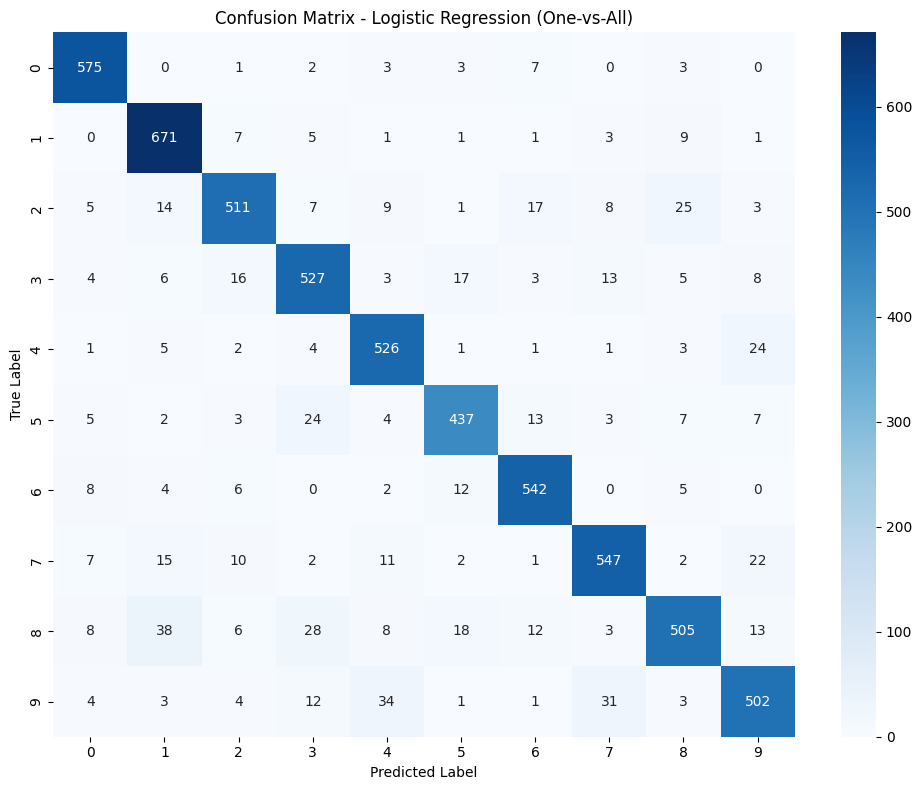


Confusion Matrix:
[[575   0   1   2   3   3   7   0   3   0]
 [  0 671   7   5   1   1   1   3   9   1]
 [  5  14 511   7   9   1  17   8  25   3]
 [  4   6  16 527   3  17   3  13   5   8]
 [  1   5   2   4 526   1   1   1   3  24]
 [  5   2   3  24   4 437  13   3   7   7]
 [  8   4   6   0   2  12 542   0   5   0]
 [  7  15  10   2  11   2   1 547   2  22]
 [  8  38   6  28   8  18  12   3 505  13]
 [  4   3   4  12  34   1   1  31   3 502]]


In [51]:
# Confusion Matrix
cm = confusion_matrix(y_val, logistic_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression (One-vs-All)')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

In [53]:
# Precision and Recall
precision_per_class = precision_score(y_val, logistic_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_val, logistic_pred, average=None, zero_division=0)

print("\nPer-Class Precision and Recall:")
print("-" * 45)
print(f"{'Digit':<8}{'Precision':<15}{'Recall':<15}")
print("-" * 45)
for i in range(10):
    print(f"{i:<8}{precision_per_class[i]:<15.4f}{recall_per_class[i]:<15.4f}")
print("-" * 45)
print(f"{'Macro Avg':<8}{np.mean(precision_per_class):<15.4f}{np.mean(recall_per_class):<15.4f}")


Per-Class Precision and Recall:
---------------------------------------------
Digit   Precision      Recall         
---------------------------------------------
0       0.9319         0.9680         
1       0.8852         0.9599         
2       0.9028         0.8517         
3       0.8625         0.8754         
4       0.8752         0.9261         
5       0.8864         0.8653         
6       0.9064         0.9361         
7       0.8982         0.8837         
8       0.8907         0.7903         
9       0.8655         0.8437         
---------------------------------------------
Macro Avg0.8905         0.8900         


In [54]:
print("\nClassification Report:")
print(classification_report(y_val, logistic_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9319    0.9680    0.9496       594
           1     0.8852    0.9599    0.9211       699
           2     0.9028    0.8517    0.8765       600
           3     0.8625    0.8754    0.8689       602
           4     0.8752    0.9261    0.8999       568
           5     0.8864    0.8653    0.8758       505
           6     0.9064    0.9361    0.9210       579
           7     0.8982    0.8837    0.8909       619
           8     0.8907    0.7903    0.8375       639
           9     0.8655    0.8437    0.8545       595

    accuracy                         0.8905      6000
   macro avg     0.8905    0.8900    0.8896      6000
weighted avg     0.8905    0.8905    0.8898      6000



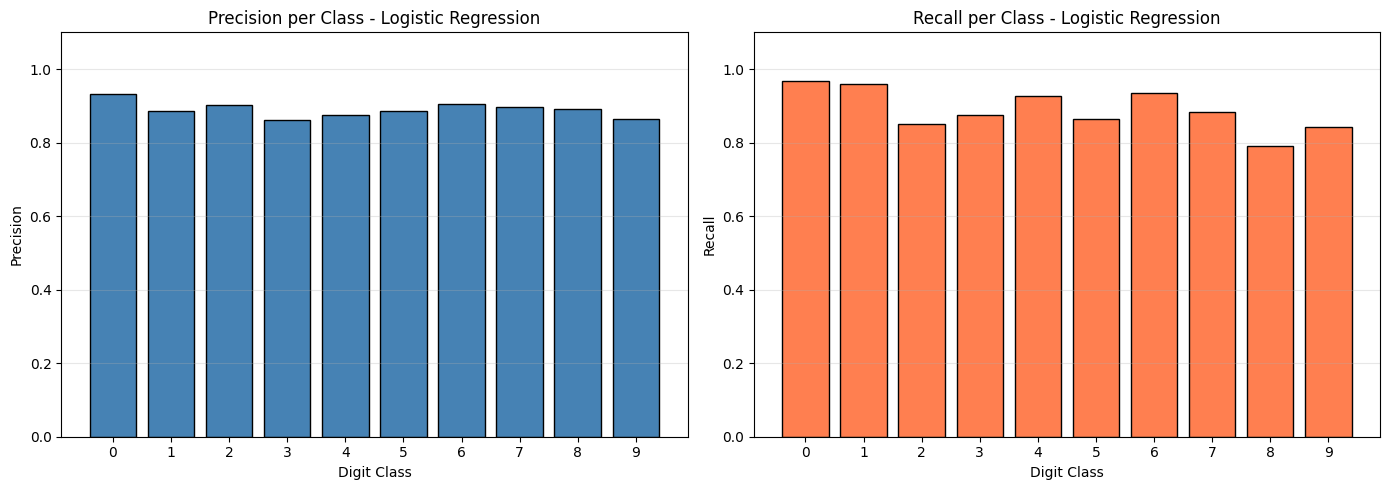

In [55]:
# Visualize Precision and Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].bar(range(10), precision_per_class, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision per Class - Logistic Regression')
axes[0].set_xticks(range(10))
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Recall plot
axes[1].bar(range(10), recall_per_class, color='coral', edgecolor='black')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall per Class - Logistic Regression')
axes[1].set_xticks(range(10))
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 CNN Model Evaluation

In [56]:
# Evaluate CNN on validation set
cnn_loss, cnn_accuracy = cnn_model.evaluate(val_dataset, verbose=0)

print("="*60)
print("CNN MODEL EVALUATION")
print("="*60)
print(f"\nValidation Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"Validation Loss: {cnn_loss:.4f}")

CNN MODEL EVALUATION

Validation Accuracy: 0.9910 (99.10%)
Validation Loss: 0.0516


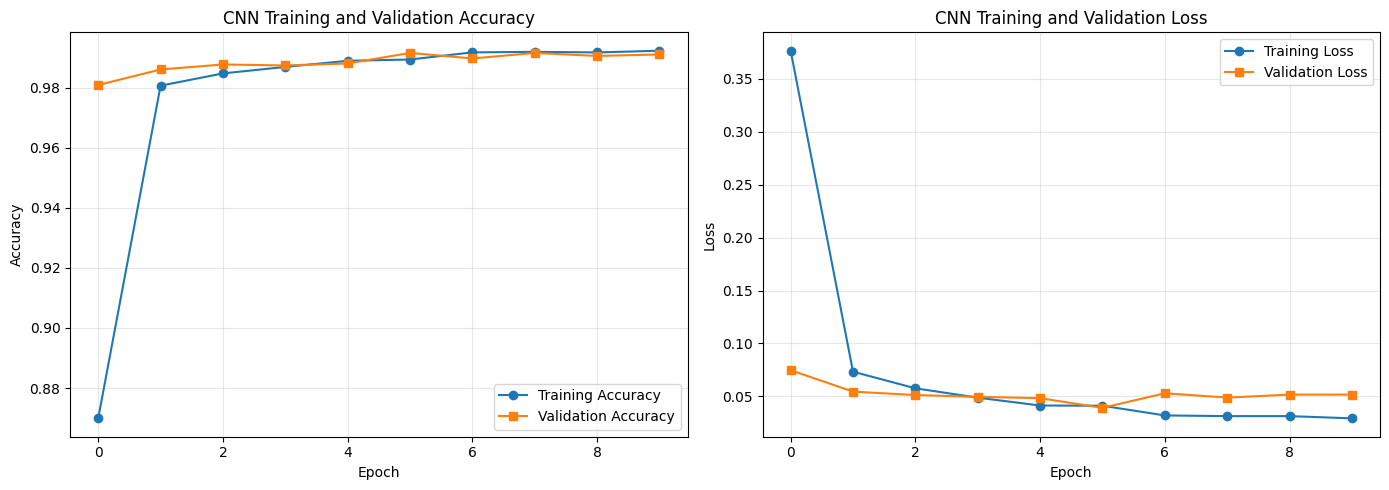

In [57]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Training and Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Model Comparison

In [58]:
# Compare both models
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"\n{'Model':<35}{'Accuracy':<15}")
print("-" * 50)
print(f"{'Logistic Regression (One-vs-All)':<35}{logistic_accuracy:<15.4f}")
print(f"{'CNN (VGG-like)':<35}{cnn_accuracy:<15.4f}")
print("-" * 50)

MODEL COMPARISON

Model                              Accuracy       
--------------------------------------------------
Logistic Regression (One-vs-All)   0.8905         
CNN (VGG-like)                     0.9910         
--------------------------------------------------


---
## 6. Prediction on New Images

This section demonstrates how to use the trained models to predict digits from new images.

In [59]:
from PIL import Image

def predict_digit(image_path, logistic_models, scaler, cnn_model):

    # Load and preprocess image
    img = Image.open(image_path).convert('L').resize((28, 28))
    img_array = np.array(img) / 255.0
    
    # Logistic Regression prediction
    x_test_flat = img_array.flatten().reshape(1, -1)
    intercept_test = np.ones((1, 1))
    x_test_with_intercept = np.concatenate((intercept_test, x_test_flat), axis=1)
    x_test_scaled = x_test_with_intercept.copy()
    x_test_scaled[:, 1:] = scaler.transform(x_test_flat)
    
    logistic_pred, logistic_conf = predict_multiclass(x_test_scaled, logistic_models)
    
    # CNN prediction
    x_test_cnn = img_array.reshape(1, 28, 28, 1)
    cnn_probs = cnn_model.predict(x_test_cnn, verbose=0)
    cnn_pred = np.argmax(cnn_probs, axis=1)[0]
    cnn_conf = np.max(cnn_probs, axis=1)[0]
    
    return {
        'image': img_array,
        'logistic_prediction': logistic_pred[0],
        'logistic_confidence': logistic_conf[0],
        'cnn_prediction': cnn_pred,
        'cnn_confidence': cnn_conf
    }

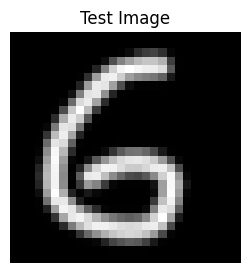

Logistic Regression Prediction: 2 (Confidence: 1.0000)
CNN Prediction: 6 (Confidence: 0.8895)


In [61]:
# Predict on a test image

test_image_path = 'test/image.png'

try:
    result = predict_digit(test_image_path, models, scaler, cnn_model)
    
    # Display results
    plt.figure(figsize=(3, 3))
    plt.imshow(result['image'], cmap='gray')
    plt.axis('off')
    plt.title('Test Image')
    plt.show()
    
    print(f"Logistic Regression Prediction: {result['logistic_prediction']} (Confidence: {result['logistic_confidence']:.4f})")
    print(f"CNN Prediction: {result['cnn_prediction']} (Confidence: {result['cnn_confidence']:.4f})")
    
except FileNotFoundError:
    print(f"Test image not found at '{test_image_path}'. Please provide a valid image path.")

---
## 7. Interpretation and Conclusion

### Results Summary

We implemented two models for handwritten digit recognition: Logistic Regression using the One-vs-All strategy with 10 binary classifiers, and a VGG-like CNN with 3 convolutional blocks. The CNN achieved higher accuracy due to its ability to capture spatial patterns in images, while logistic regression provided a simpler, interpretable concept. The One-vs-All approach proved effective for multi-class classification, with each binary classifier distinguishing one digit from all others and the final prediction determined by maximum probability.

### Key Insights

**Model Performance:**
- The CNN model generally outperforms logistic regression due to its ability to learn spatial patterns
- Logistic regression achieves reasonable accuracy despite being a simpler linear model
- Both models benefit from proper preprocessing (normalization, scaling)

**One-vs-All Strategy:**
- Effective for multi-class classification with binary classifiers
- Each classifier learns to distinguish one digit from all others
- Final prediction based on maximum probability across all classifiers
